In [1]:
import CONSTANTS

In [2]:
import pandas as pd
from DataLoader import get_setup_files_with_folds
import numpy as np
import math

In [4]:

# List to store data for the DataFrame
results = []

# for dataset_name, date_tag in dataset_info.items():
# for dataset_name in CONSTANTS.DATASET_COLUMN.keys():
for dataset_name in ['Alkane_Carbonyl']:
    # for algo in ['RBRICS']:
    for algo in ["PRESERVE_ALKANE_CARBONYL"]:
        date_tag = f"{algo}{CONSTANTS.CHOSEN_THRESHOLD[algo][dataset_name]}"
        for fold in [0, 1, 2, 3, 4]:
            lookup, motif_list, motif_counts, motif_lengths, motif_class_count, graph_to_motifs, test_data_lookup, test_graph_to_motifs, train_mask_data, val_mask_data, test_mask_data = get_setup_files_with_folds(dataset_name, date_tag, fold, algo)
            
            # Compute values
            total_train_val_graphs = len(lookup)
            vocab_size = len(motif_list)
            total_test_graphs = len(test_data_lookup)
            graphs_with_motifs_train_val = len(graph_to_motifs.keys())
            total_unique_motifs_train_val = sum([val for values in graph_to_motifs.values() for val in values])
            graphs_with_motifs_test = len(test_graph_to_motifs.keys())
            total_unique_motifs_test = sum([val for values in test_graph_to_motifs.values() for val in values])
            highest_vocab_size = len(motif_counts)
            # Calculate mean
            values = [motif_lengths[key] for key in motif_list if key in motif_lengths]
            mean_motif_length = sum(values) / len(values)

            # Calculate standard deviation
            variance = sum((x - mean_motif_length) ** 2 for x in values) / len(values)
            std_dev_length = math.sqrt(variance)
            
            # Calculate mean
            values = [motif_counts[key] for key in motif_list if key in motif_counts]
            mean_motif_freq = sum(values) / len(values)

            # Calculate standard deviation
            variance = sum((x - mean_motif_freq) ** 2 for x in values) / len(values)
            std_dev_motif_freq = math.sqrt(variance)

            all_possible_occurrences = sum([values for values in motif_counts.values()])
            
            # Add data to results
            results.append({
                'Dataset': dataset_name,
                'DateTag': date_tag,
                'Algorithm': algo,
                'Fold': fold,
                'TotalGraphs_TrainVal': total_train_val_graphs,
                'VocabSize': vocab_size,
                'TotalGraphs_Test': total_test_graphs,
                'GraphsWithMotifs_TrainVal': graphs_with_motifs_train_val,
                'TotalUniqueMotifs_TrainVal': total_unique_motifs_train_val,
                'GraphsWithMotifs_Test': graphs_with_motifs_test,
                'TotalUniqueMotifs_Test': total_unique_motifs_test,
                'HighestVocabSize': highest_vocab_size,
                'AllPossibleOccurrences': all_possible_occurrences,
                'Mean Length': mean_motif_length,
                'Std length':std_dev_length,
                'Mean Frequency': mean_motif_freq,
                'Std Frequency':std_dev_motif_freq,
            })

# Create a DataFrame from the results
df = pd.DataFrame(results)

# # Save to a CSV file (optional)
# df.to_csv('dataset_statistics.csv', index=False)

# Display the DataFrame
print(df)


           Dataset                      DateTag                 Algorithm   
0  Alkane_Carbonyl  PRESERVE_ALKANE_CARBONYL0.5  PRESERVE_ALKANE_CARBONYL  \
1  Alkane_Carbonyl  PRESERVE_ALKANE_CARBONYL0.5  PRESERVE_ALKANE_CARBONYL   
2  Alkane_Carbonyl  PRESERVE_ALKANE_CARBONYL0.5  PRESERVE_ALKANE_CARBONYL   
3  Alkane_Carbonyl  PRESERVE_ALKANE_CARBONYL0.5  PRESERVE_ALKANE_CARBONYL   
4  Alkane_Carbonyl  PRESERVE_ALKANE_CARBONYL0.5  PRESERVE_ALKANE_CARBONYL   

   Fold  TotalGraphs_TrainVal  VocabSize  TotalGraphs_Test   
0     0                  3892        147               434  \
1     1                  3892        158               434   
2     2                  3892        156               434   
3     3                  3892        164               434   
4     4                  3892        162               434   

   GraphsWithMotifs_TrainVal  TotalUniqueMotifs_TrainVal   
0                       3729                      462727  \
1                       3723                

In [ ]:
input()

In [ ]:
df.columns

In [4]:
# Select relevant columns
selected_columns = ['Dataset', 'Algorithm', 'Fold', 'VocabSize', 'Mean Length', 'Std length', 'Mean Frequency', 'Std Frequency','TotalGraphs_TrainVal','GraphsWithMotifs_TrainVal']
df_selected = df[selected_columns]

# Group by 'Dataset_Fold' and calculate mean
grouped = df_selected.groupby(['Dataset','Algorithm']).agg({'VocabSize':'mean','Mean Length': 'mean', 'Mean Frequency': 'mean','TotalGraphs_TrainVal':'mean','GraphsWithMotifs_TrainVal':'mean'})

grouped['Graph Coverage'] = grouped['GraphsWithMotifs_TrainVal']/grouped['TotalGraphs_TrainVal']
# Reset index to remove Dataset_Fold column
result = grouped.reset_index()

print(result)

             Dataset Algorithm  VocabSize  Mean Length  Mean Frequency   
0    Alkane_Carbonyl    RBRICS      154.8     4.688100      114.798903  \
1               BBBP    RBRICS      222.8     5.485442       35.977598   
2            Benzene    RBRICS      116.4     4.262807      383.963798   
3  Fluoride_Carbonyl    RBRICS      198.4     4.866688      156.509785   
4      Lipophilicity    RBRICS      148.4     5.372962      137.384940   
5       Mutagenicity    RBRICS      190.0     4.730030       96.680008   
6               esol    RBRICS      174.2     5.175698       13.659506   
7               hERG    RBRICS      180.2     5.064861      284.470870   
8              tox21    RBRICS      219.0     4.466679      118.005645   

   TotalGraphs_TrainVal  GraphsWithMotifs_TrainVal  Graph Coverage  
0                3892.0                     3764.6        0.967266  
1                1672.0                     1565.2        0.936124  
2               10783.2                    10354.4  

In [ ]:
result.to_latex("vocab_info_0205.tex")

In [ ]:
result.to_csv('vocab_statistics_grouped.csv', index=False)

In [ ]:
df.to_csv('dataset_statistics.csv', index=False)

In [4]:
# ADDITIONAL ANALYSIS: Calculate mean length of ALL motifs including those not in vocabulary
print("=== ADDITIONAL ANALYSIS: All Motifs Including Non-Vocabulary ===")

# Create enhanced results with all motifs analysis
enhanced_results = []

for dataset_name in CONSTANTS.DATASET_COLUMN.keys():
    for algo in ['RBRICS']:
        date_tag = f"{algo}{CONSTANTS.CHOSEN_THRESHOLD[algo][dataset_name]}"
        for fold in [0, 1, 2, 3, 4]:
            lookup, motif_list, motif_counts, motif_lengths, motif_class_count, graph_to_motifs, test_data_lookup, test_graph_to_motifs, train_mask_data, val_mask_data, test_mask_data = get_setup_files_with_folds(dataset_name, date_tag, fold, algo, path= "/nfs/stak/users/kokatea/hpc-share/ChemIntuit/MOSE-GNN/DICTIONARY")
            
            # input(motif_list)
            
            #Get Motif Length, Freq per graph
            local_motif_df = pd.read_csv(f"datasets/csv_exports/{dataset_name}_{fold}_{algo}.csv")
            
            # Calculate mean length for vocabulary motifs only (in motif_list)
            vocab_values = [motif_lengths[key] for key in motif_list if key in motif_lengths]
            mean_motif_length = sum(vocab_values) / len(vocab_values) if vocab_values else 0

            # Calculate standard deviation for vocabulary motifs
            variance = sum((x - mean_motif_length) ** 2 for x in vocab_values) / len(vocab_values) if vocab_values else 0
            std_dev_length = math.sqrt(variance)
            
            # Calculate mean length for ALL motifs (including those not in vocabulary)
            all_motif_lengths = list(local_motif_df["Motif Length"])
            mean_all_motif_length = sum(all_motif_lengths) / len(all_motif_lengths) if all_motif_lengths else 0
            
            # Calculate standard deviation for ALL motifs
            all_variance = sum((x - mean_all_motif_length) ** 2 for x in all_motif_lengths) / len(all_motif_lengths) if all_motif_lengths else 0
            std_dev_all_length = math.sqrt(all_variance)
            
            # Count motifs not in vocabulary (these are like "UNK" motifs)
            non_vocab_motifs = set(local_motif_df["Motif String"]) - set(motif_list)
            non_vocab_count = len(non_vocab_motifs)
            total_all_motifs = local_motif_df["Motif String"].nunique()
            
            # Calculate mean frequency for vocabulary motifs only
            freq_values = [motif_counts[key] for key in motif_list if key in motif_counts]
            mean_motif_freq = sum(freq_values) / len(freq_values) if freq_values else 0

            # Calculate standard deviation for frequency
            freq_variance = sum((x - mean_motif_freq) ** 2 for x in freq_values) / len(freq_values) if freq_values else 0
            std_dev_motif_freq = math.sqrt(freq_variance)
            
            mean_all_motif_freq = local_motif_df.groupby("Motif String")["Motif Frequency"].sum().mean()
            std_dev_all_freq   = local_motif_df.groupby("Motif String")["Motif Frequency"].sum().std(ddof=0)  # population


            enhanced_results.append({
                'Dataset': dataset_name,
                'DateTag': date_tag,
                'Algorithm': algo,
                'Fold': fold,
                'VocabSize': len(motif_list),
                'Mean Length (Vocab Only)': mean_motif_length,
                'Std Length (Vocab Only)': std_dev_length,
                'Mean Length (All Motifs)': mean_all_motif_length,
                'Std Length (All Motifs)': std_dev_all_length,
                'Non-Vocab Motif Count': non_vocab_count,
                'Total All Motifs': total_all_motifs,
                'Mean Frequency': mean_motif_freq,
                'Std Frequency': std_dev_motif_freq,
                'Mean Frequency (All Motifs)': mean_all_motif_freq,
                'Std Frequency (All Motifs)': std_dev_all_freq,
            })

# Create enhanced DataFrame
enhanced_df = pd.DataFrame(enhanced_results)

# Display enhanced results
print("\nEnhanced Results with All Motifs Analysis:")
print(enhanced_df)

# Group by dataset and calculate averages
enhanced_grouped = enhanced_df.groupby(['Dataset','Algorithm']).agg({
    'VocabSize': 'mean',
    'Mean Length (Vocab Only)': 'mean', 
    'Mean Length (All Motifs)': 'mean',
    'Non-Vocab Motif Count': 'mean',
    'Total All Motifs': 'mean',
    'Mean Frequency': 'mean',
    'Mean Frequency (All Motifs)': 'mean',
}).round(3)

enhanced_grouped = enhanced_grouped.reset_index()

print("\nAveraged Results Across Folds:")
print(enhanced_grouped)

# Save enhanced results
enhanced_df.to_csv(f'plots/enhanced_dataset_statistics_{date_tag}.csv', index=False)
enhanced_grouped.to_csv(f'plots/enhanced_vocab_statistics_grouped_{date_tag}.csv', index=False)

print("\n✅ Enhanced analysis complete! Files saved:")
print("- enhanced_dataset_statistics.csv")
print("- enhanced_vocab_statistics_grouped.csv")

=== ADDITIONAL ANALYSIS: All Motifs Including Non-Vocabulary ===

Enhanced Results with All Motifs Analysis:
              Dataset    DateTag Algorithm  Fold  VocabSize   
0        Mutagenicity  RBRICS0.2    RBRICS     0        189  \
1        Mutagenicity  RBRICS0.2    RBRICS     1        193   
2        Mutagenicity  RBRICS0.2    RBRICS     2        193   
3        Mutagenicity  RBRICS0.2    RBRICS     3        186   
4        Mutagenicity  RBRICS0.2    RBRICS     4        189   
5                hERG  RBRICS0.5    RBRICS     0        183   
6                hERG  RBRICS0.5    RBRICS     1        176   
7                hERG  RBRICS0.5    RBRICS     2        183   
8                hERG  RBRICS0.5    RBRICS     3        181   
9                hERG  RBRICS0.5    RBRICS     4        178   
10               BBBP  RBRICS0.6    RBRICS     0        221   
11               BBBP  RBRICS0.6    RBRICS     1        223   
12               BBBP  RBRICS0.6    RBRICS     2        225   
13       

In [30]:
from rdkit import Chem
from rdkit.Chem import BRICS
from rdkit.Chem.Draw import rdMolDraw2D
from collections import Counter, defaultdict
from io import BytesIO
from PIL import Image, ImageDraw
import numpy as np
import pandas as pd

CSV_PATH = "datasets/_Benzene.csv"
MAX_ROWS = 200
N_SHOW = 9
THRESHOLDS = [0, 2, 4, 6, 8, 10]

# ---------- Load ----------
df = pd.read_csv(CSV_PATH).head(MAX_ROWS)
if "smiles" not in df.columns:
    raise ValueError("CSV must contain a 'smiles' column.")

mols = []
for s in df["smiles"].astype(str).fillna(""):
    m = Chem.MolFromSmiles(s)
    if m is None:
        continue
    try:
        Chem.Kekulize(m, clearAromaticFlags=True)
    except Exception:
        pass
    mols.append(m)

if len(mols) == 0:
    raise ValueError("No valid molecules found.")

def _canonicalize_fragment(frag_mol):
    frag_mol = Chem.Mol(frag_mol)
    for atom in frag_mol.GetAtoms():
        if atom.GetAtomicNum() == 0:
            atom.SetAtomicNum(1)
            atom.SetFormalCharge(0)
    try:
        Chem.SanitizeMol(frag_mol)
    except Exception:
        pass
    return Chem.MolToSmiles(frag_mol, isomericSmiles=True, canonical=True)

def fragment_brics_with_mapping_by_submols(mol):
    mol = Chem.Mol(mol)
    for a in mol.GetAtoms():
        a.SetIntProp("_origIdx", a.GetIdx())

    bonds = BRICS.FindBRICSBonds(mol)
    if not bonds:
        frag_mols = [Chem.Mol(mol)]
    else:
        bond_indices = []
        for (a1, a2), _ in bonds:
            b = mol.GetBondBetweenAtoms(int(a1), int(a2))
            if b is not None:
                bond_indices.append(b.GetIdx())
        if not bond_indices:
            frag_mols = [Chem.Mol(mol)]
        else:
            fmol = Chem.FragmentOnBonds(mol, bond_indices, addDummies=True)
            frag_mols = Chem.GetMolFrags(fmol, asMols=True, sanitizeFrags=True)

    frag_smiles = []
    per_frag_atoms = []
    for f in frag_mols:
        frag_smiles.append(_canonicalize_fragment(f))
        atom_set = set()
        for a in f.GetAtoms():
            if a.HasProp("_origIdx"):
                atom_set.add(a.GetIntProp("_origIdx"))
        per_frag_atoms.append(atom_set)
    return frag_smiles, per_frag_atoms

# Build
per_mol_fraginfo = []
motif_counts = Counter()
for m in mols:
    fr_smi, fr_atoms = fragment_brics_with_mapping_by_submols(m)
    per_mol_fraginfo.append({"mol": m, "frag_smiles": fr_smi, "frag_atoms": fr_atoms})
    motif_counts.update(fr_smi)

# Select molecules rich in common motifs
TOPK = 10
top_motifs = [s for s, _ in motif_counts.most_common(TOPK)]
def mol_score(info):
    return sum(1 for s in set(info["frag_smiles"]) if s in top_motifs)
scored = sorted(per_mol_fraginfo, key=mol_score, reverse=True)
selected = scored[:N_SHOW]

def draw_molecule_highlighting_fragset(mol, frag_smiles_list, frag_atoms_list, kept_set, size=(260, 260)):
    highlight_atoms = set()
    for s, atoms in zip(frag_smiles_list, frag_atoms_list):
        if s in kept_set:
            highlight_atoms.update(atoms)
    d = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])
    rdMolDraw2D.PrepareAndDrawMolecule(d, mol, highlightAtoms=list(highlight_atoms))
    d.FinishDrawing()
    return Image.open(BytesIO(d.GetDrawingText()))

from PIL import Image, ImageDraw, ImageFont

def make_grid(images, threshold_label, cols=3, bg="white", scale=4, pad=8):
    """Render black text without any TTF dependency."""
    w, h = images[0].size
    rows = -(-len(images) // cols)  # ceil division

    # Render small black text
    font = ImageFont.load_default()
    label = f"Frequency > {threshold_label}"

    tmp = Image.new("L", (1, 1), 0)
    dtmp = ImageDraw.Draw(tmp)
    l, t, r, b = dtmp.textbbox((0, 0), label, font=font)
    tw, th = r - l, b - t

    # Draw text in white on black background, then invert for crisp black
    text_img = Image.new("L", (tw, th), 255)  # white background
    d = ImageDraw.Draw(text_img)
    d.text((0, 0), label, fill=0, font=font)  # black text (fill=0)

    # Upscale smoothly
    text_big = text_img.resize((tw * scale, th * scale), Image.NEAREST)

    # Compose final grid
    title_h = text_big.height + 2 * pad
    grid = Image.new("RGB", (cols * w, rows * h + title_h), bg)

    # Optional banner background for contrast
    banner_color = (240, 240, 240)
    grid.paste(Image.new("RGB", (grid.width, title_h), banner_color), (0, 0))

    # Paste centered black text
    text_rgb = Image.merge("RGB", (text_big, text_big, text_big))
    x = (grid.width - text_big.width) // 2
    y = (title_h - text_big.height) // 2
    grid.paste(text_rgb, (x, y))

    # Paste molecules
    y0 = title_h
    for i, im in enumerate(images):
        r, c = divmod(i, cols)
        grid.paste(im, (c * w, y0 + int(r/2) * h))

    return grid


frames = []
for t in THRESHOLDS:
    kept = {s for s, c in motif_counts.items() if c > t}
    imgs = [draw_molecule_highlighting_fragset(info["mol"], info["frag_smiles"], info["frag_atoms"], kept) for info in selected]
    frame = make_grid(imgs, threshold_label=t)
    frames.append(frame)

gif_path = "plots/motif_thresholds_clean.gif"
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=1200, loop=0, format="GIF")
gif_path


[19:55:28] Explicit valence for atom # 8 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 11 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 11 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 4 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 4 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 7 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 3 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 2 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 10 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 11 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 4 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 3 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 4 H, 2, is greater than permitted
[19:55:28] Explicit valence for atom # 8 H, 2, 

'plots/motif_thresholds_clean.gif'

# Motif level distribution

In [6]:
#!/usr/bin/env python3
import pandas as pd
from rdkit import Chem
from collections import Counter
import torch
# ===== IMPORT FUNCTIONS =====
from Utils.Utils_vocab import (
    process_molecule,
    fragment_molecule,
    add_fragment,
    MotifDictionary
)

# ==========================================
# PROCESS DATASET USING rBRICS
# ==========================================

def process_dataset_rbrics(smiles_list, labels):
    lookup = MotifDictionary()

    for smi, y in zip(smiles_list, labels):
        try:
            mol = process_molecule(smi, True)

            # Recursive BRICS = RBRICS mode
            frags = fragment_molecule(mol, recursive=True)

            # Provide data object with simple attributes
            data_obj = type("obj", (), {
                "y": torch.tensor([y], dtype=torch.float),
                "smiles": smi
            })
            for frag in frags:
                add_fragment(frag, smi, data_obj, lookup, is_test=False)

        except Exception as e:
            print(f"Skipping molecule {smi}: {e}")

    return lookup


# ==========================================
# RANK MOTIFS BY CLASS SEPARATION
# ==========================================

def rank_motifs_by_class(lookup):
    class0 = Counter()
    class1 = Counter()

    for motif, graphmap in lookup.motifs_class.items():
        for _, label in graphmap.items():

            # label must be scalar
            label = int(label)

            if label == 1:
                class1[motif] += 1
            elif label == 0:
                class0[motif] += 1

    results = []
    for m in set(class0) | set(class1):
        results.append({
            "motif": m,
            "class_0_count": class0[m],
            "class_1_count": class1[m],
            "total_count": class0[m] + class1[m],
            "delta(class1-class0)": class1[m] - class0[m]
        })

    df = pd.DataFrame(results)
    df = df.sort_values(by="delta(class1-class0)", ascending=False)
    return df


# ==========================================
# MAIN
# ==========================================

if __name__ == "__main__":
    csv_path = "datasets/FOLDS/Alkane_Carbonyl_0.csv"
    df = pd.read_csv(csv_path)

    smiles = df["smiles"].tolist()
    labels = df["label"].tolist()

    lookup = process_dataset_rbrics(smiles, labels)
    ranking_df = rank_motifs_by_class(lookup)

    ranking_df.to_csv("motif_class_ranking_rbrics.csv", index=False)

    print("\n===== TOP 20 MOTIFS ENRICHED IN CLASS 1 =====")
    print(ranking_df.head(20))

    print("\n===== TOP 20 MOTIFS ENRICHED IN CLASS 0 =====")
    print(ranking_df.tail(20))



===== TOP 20 MOTIFS ENRICHED IN CLASS 1 =====
                   motif  class_0_count  class_1_count  total_count   
2865           *CCC(*)=O             31             68           99  \
280              *C(*)=O            479            516          995   
834           *CCCC(*)=O              0             25           25   
2922        *C(=O)C(*)=O             10             26           36   
1313            *CC(*)=O            190            203          393   
2757           *C(=O)CCC              0             11           11   
23                 *CCC*             91            102          193   
937               *CCCC*             12             17           29   
66                 *=CCC              0              5            5   
499       *C(=O)C(=*)C#N              4              8           12   
435       *CCCS(C)(=O)=O              1              5            6   
1910      *[NH+]1CCCCC1C              2              6            8   
84               *CCCC=C      

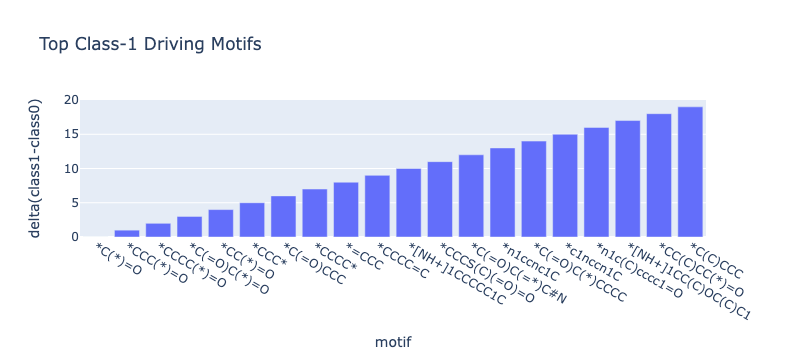

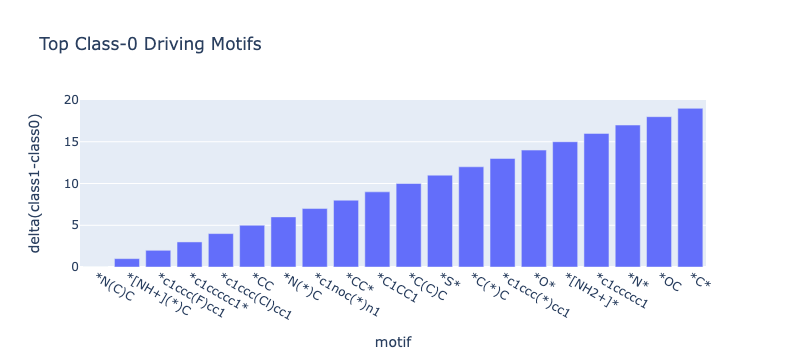

In [7]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("motif_class_ranking_rbrics.csv")
df = df.sort_values("delta(class1-class0)", ascending=False)

fig = px.bar(df.head(20),
             x="motif",
             y="delta(class1-class0)",
             title="Top Class-1 Driving Motifs",
             hover_data=["class_0_count","class_1_count","total_count"])
fig.show()

fig2 = px.bar(df.tail(20),
             x="motif",
             y="delta(class1-class0)",
             title="Top Class-0 Driving Motifs",
             hover_data=["class_0_count","class_1_count","total_count"])
fig2.show()


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from scipy.sparse import lil_matrix
import numpy as np

# ===========================
# LOAD DATA
# ===========================
motif_df = pd.read_csv("motif_class_ranking_rbrics.csv")
raw_df   = pd.read_csv("datasets/FOLDS/Alkane_Carbonyl_0.csv")

smiles = raw_df["smiles"].tolist()
labels = raw_df["label"].values

# ===========================
# BUILD MOTIF‒VOCAB INDEX
# ===========================
motifs = motif_df["motif"].tolist()
motif_to_idx = {m:i for i,m in enumerate(motifs)}

n_mols   = len(smiles)
n_motifs = len(motifs)

X = lil_matrix((n_mols, n_motifs), dtype=int)

# ===========================
# POPULATE MATRIX
# ===========================
from Utils.Utils_vocab import (
    process_molecule,
    fragment_molecule,
)

print("Building motif matrix...")
for i, smi in enumerate(smiles):
    try:
        mol = process_molecule(smi, True)
        frags = fragment_molecule(mol, recursive=True)
        seen = set()
        for frag in frags:
            f = Chem.MolToSmiles(frag, isomericSmiles=False, canonical=True)
            if f in motif_to_idx:
                seen.add(motif_to_idx[f])
        for idx in seen:
            X[i, idx] = 1
    except:
        pass

X = X.tocsr()


Building motif matrix...


In [10]:
#!/usr/bin/env python3

import pandas as pd
import numpy as np
from scipy.sparse import lil_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier

from rdkit import Chem

# -----------------------------------------------------
# IMPORT YOUR UTILITIES
# -----------------------------------------------------
from Utils.Utils_vocab import (
    process_molecule,
    fragment_molecule,
)

# -----------------------------------------------------
# GLOBAL SETTINGS
# -----------------------------------------------------
MOTIF_CSV = "motif_class_ranking_rbrics.csv"
DATASET   = "datasets/FOLDS/Alkane_Carbonyl_0.csv"

# -----------------------------------------------------
# NORMALIZE RBRICS FRAGMENT → MOTIF FORMAT
# -----------------------------------------------------
def normalize_fragment_to_motif_smi(frag):
    """
    Converts a raw RDKit fragment into the same canonical format
    used by your motif vocabulary: removes atom maps, canonicalizes,
    removes stereo, removes charges, etc.
    """
    frag = Chem.Mol(frag)
    for a in frag.GetAtoms():
        a.SetAtomMapNum(0)

    smi = Chem.MolToSmiles(
        frag,
        isomericSmiles=False,
        canonical=True,
        doRandom=False
    )
    
    return smi


# -----------------------------------------------------
# 1. LOAD MOTIF VOCABULARY
# -----------------------------------------------------
motif_df = pd.read_csv(MOTIF_CSV)
motifs = motif_df["motif"].tolist()
motif_to_idx = {m:i for i,m in enumerate(motifs)}

print(f"Loaded {len(motifs)} motifs.")


# -----------------------------------------------------
# 2. LOAD DATASET
# -----------------------------------------------------
raw_df = pd.read_csv(DATASET)
smiles  = raw_df["smiles"].tolist()
labels  = raw_df["label"].astype(int).values

n_mols   = len(smiles)
n_motifs = len(motifs)

print(f"Loaded {n_mols} molecules.")


# -----------------------------------------------------
# 3. BUILD MOTIF PRESENCE MATRIX
# -----------------------------------------------------
X = lil_matrix((n_mols, n_motifs), dtype=int)

print("\nGenerating motif presence matrix...")
count_mols_with_motifs = 0

for i, smi in enumerate(smiles):
    try:
        mol = process_molecule(smi, True)
        frags = fragment_molecule(mol, recursive=True)

        seen = set()

        for frag in frags:
            f_norm = normalize_fragment_to_motif_smi(frag)
            if f_norm in motif_to_idx:
                seen.add(motif_to_idx[f_norm])

        if len(seen) > 0:
            count_mols_with_motifs += 1

        for idx in seen:
            X[i, idx] = 1

    except Exception as e:
        print(f"Skipping {smi} → {e}")

X = X.tocsr()
nonzero = X.sum()

print(f"Matrix built.")
print(f"Non-zero entries: {nonzero}")
print(f"Molecules with ≥1 matched motif: {count_mols_with_motifs}\n")


# -----------------------------------------------------
# 4. TRAIN TEST SPLIT
# -----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.25, random_state=0
)


# -----------------------------------------------------
# 5. LOGISTIC REGRESSION CLASSIFIER
# -----------------------------------------------------
logit = LogisticRegression(max_iter=5000)
logit.fit(X_train, y_train)

pred = logit.predict_proba(X_test)[:,1]

auc  = roc_auc_score(y_test, pred)
acc  = accuracy_score(y_test, (pred > 0.5).astype(int))

print("=== Logistic Regression ===")
print("ROC-AUC:", round(auc, 4))
print("ACC:",     round(acc, 4))


# FEATURE IMPORTANCE
coef_df = pd.DataFrame({
    "motif": motifs,
    "coef": logit.coef_.ravel()
})
coef_df = coef_df.sort_values("coef", ascending=False)

print("\nTop class-1 motifs:")
print(coef_df.head(10), "\n")

print("Top class-0 motifs:")
print(coef_df.tail(10), "\n")


# -----------------------------------------------------
# 6. RANDOM FOREST CLASSIFIER
# -----------------------------------------------------
rf = RandomForestClassifier(n_estimators=400)
rf.fit(X_train, y_train)

pred2 = rf.predict_proba(X_test)[:,1]

auc2  = roc_auc_score(y_test, pred2)
acc2  = accuracy_score(y_test, (pred2 > 0.5).astype(int))

print("=== Random Forest ===")
print("ROC-AUC:", round(auc2, 4))
print("ACC:",     round(acc2, 4))


Loaded 2972 motifs.
Loaded 4326 molecules.

Generating motif presence matrix...
Matrix built.
Non-zero entries: 20761
Molecules with ≥1 matched motif: 4326

=== Logistic Regression ===
ROC-AUC: 0.8935
ACC: 0.8706

Top class-1 motifs:
               motif      coef
2         *CCCC(*)=O  3.545239
0          *CCC(*)=O  2.769592
79              *CCC  2.321567
2595           *CCCC  2.207591
3       *C(=O)C(*)=O  2.167056
1            *C(*)=O  2.125900
5          *C(=O)CCC  2.069158
6              *CCC*  1.978272
4           *CC(*)=O  1.937567
10    *CCCS(C)(=O)=O  1.741489 

Top class-0 motifs:
                    motif      coef
2726         *c1nnc(C)n1* -1.047618
2908          *c1cnn(*)c1 -1.107375
2926             *c1ccsc1 -1.111096
2710  *c1cc(*)c(*)c(Cl)c1 -1.146039
2854     *c1ccc(*)c(Cl)c1 -1.147895
2831      *c1cc(Cl)ccc1Cl -1.159942
2948             *CC(O)C* -1.205081
2934        *c1ccc(Br)cc1 -1.303027
2928            *c1ccncc1 -1.477089
2931          *c1nnc(*)o1 -1.507513 

=== R